# Decision trees: splitting from scratch, and the depth dial

A decision tree asks one question at a time — *is this feature above or below
some threshold?* — and keeps asking until the group of examples left in front
of it is (nearly) pure. Nothing is estimated in the sense lessons 3 and 4 used
the word: no coefficient, no gradient. Only a sequence of yes/no questions,
chosen greedily.

That makes trees the first method in this course that can carve out an
arbitrary shape — including several disconnected regions — because each
question only ever cuts the plane along one axis, and a handful of axis-aligned
cuts can approximate almost anything. It also makes them the first method
whose single biggest danger is asking too many questions: a tree deep enough
always reaches 100% training accuracy, on any dataset, including ones with no
structure at all.

By the end you will have:

1. implemented Gini-impurity splitting and a recursive tree builder from
   scratch, and checked it against scikit-learn's `DecisionTreeClassifier`;
2. watched training and cross-validated accuracy diverge as depth grows, and
   found the depth that trades them off best;
3. seen why a single tree is an unstable model — the reason the next notebook
   exists.

Handout: `Docs/trees_and_ensembles.md`, sections 1-3.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from loan_data import load_loans

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227"

RNG_SEED = 42
np.random.seed(RNG_SEED)

X, y = load_loans()
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
print(f"{len(X)} applicants, {y.mean():.1%} defaulted")

1200 applicants, 38.7% defaulted


## 1. Look at it first

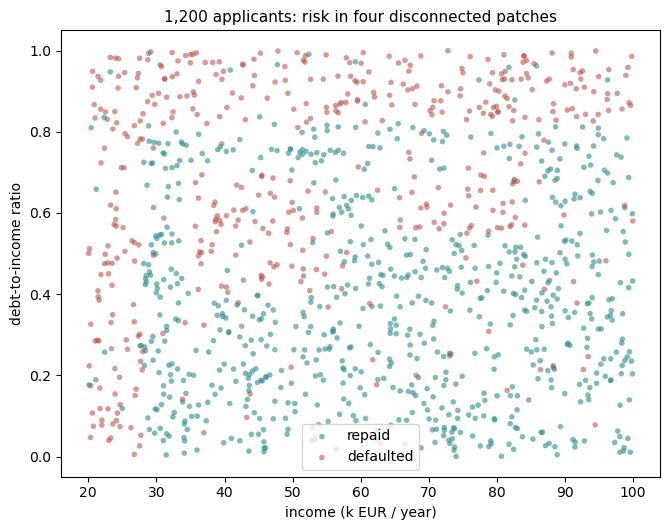

In [2]:
fig, ax = plt.subplots(figsize=(6.8, 5.4))
healthy, default = y == 0, y == 1
ax.scatter(X.loc[healthy, "income_k"], X.loc[healthy, "debt_ratio"],
           s=16, color=TEAL, alpha=.6, label="repaid", edgecolor="none")
ax.scatter(X.loc[default, "income_k"], X.loc[default, "debt_ratio"],
           s=16, color=RUST, alpha=.55, label="defaulted", edgecolor="none")
ax.set_xlabel("income (k EUR / year)"); ax.set_ylabel("debt-to-income ratio")
ax.set_title("1,200 applicants: risk in four disconnected patches", fontsize=11)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "loan_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**No straight line separates these classes**, and unlike lesson 6's pump
data, it is not one class surrounded by the other either. There are four
separate risky patches: a strip of low income on the left, a strip of high
debt at the top, and two "stressed" rectangles in between where income and
debt are each unremarkable alone but risky together. A linear model has to
draw one boundary through the whole plane; it cannot wall off four
disconnected regions with a single line.

Confirm what that costs before building anything new.

In [3]:
baseline = max(y.mean(), 1 - y.mean())
logistic = cross_val_score(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000)),
    X, y, cv=folds, scoring="accuracy")

print(f"always predict the majority class : {baseline:.3f}")
print(f"logistic regression               : {logistic.mean():.3f} "
      f"+/- {logistic.std():.3f}")

always predict the majority class : 0.613
logistic regression               : 0.748 +/- 0.030


Logistic regression clears the baseline by a wide margin this time — it is
not the flat failure lesson 6 opened with, because three of the four risky
regions are at least monotonic in one feature (very low income, very high
debt), and a linear boundary captures monotonic effects reasonably well. What
it cannot do is wall off the two *interior* islands without also cutting into
healthy territory elsewhere, and that gap is exactly what the rest of this
notebook measures.

## 2. A decision tree, split by split

The whole algorithm, applied recursively:

> Find the single (feature, threshold) split that makes the two resulting
> groups as pure as possible. Apply it. Repeat on each group until a stopping
> rule is met.

"As pure as possible" needs a number. The standard one for classification is
the **Gini impurity** of a group of examples:

$$G = 1 - \sum_{c} p_c^2$$

where $p_c$ is the fraction of the group belonging to class $c$. A pure group
(everyone the same class) has $G = 0$; a 50/50 group of two classes has
$G = 1 - (0.5^2 + 0.5^2) = 0.5$, its maximum for two classes.

A split is scored by how much it reduces impurity, weighted by how the group
is divided:

$$\Delta G = G(\text{parent}) - \left(\frac{n_L}{n} G(\text{left}) + \frac{n_R}{n} G(\text{right})\right)$$

The tree tries every feature and, for a continuous feature, the midpoint
between every pair of adjacent sorted values as a candidate threshold, and
keeps whichever $(\text{feature}, \text{threshold})$ pair maximises $\Delta G$.
Then it does the same thing again inside each child, independently, until a
child is pure or a depth limit is reached.

In [4]:
def gini(labels):
    if len(labels) == 0:
        return 0.0
    p = np.bincount(labels, minlength=2) / len(labels)
    return 1.0 - np.sum(p ** 2)


def best_split(features, labels):
    # Scan every feature and every candidate threshold; return the best.
    best_gain, best_feature, best_threshold = -1.0, None, None
    parent_impurity = gini(labels)
    n = len(labels)
    for feature in features.columns:
        values = np.sort(np.unique(features[feature].values))
        thresholds = (values[:-1] + values[1:]) / 2
        for threshold in thresholds:
            left = features[feature].values <= threshold
            if left.sum() == 0 or (~left).sum() == 0:
                continue
            weighted = (left.sum() * gini(labels[left])
                        + (~left).sum() * gini(labels[~left])) / n
            gain = parent_impurity - weighted
            if gain > best_gain:
                best_gain, best_feature, best_threshold = gain, feature, threshold
    return best_feature, best_threshold, best_gain


class Node:
    def __init__(self):
        self.feature = self.threshold = self.left = self.right = None
        self.prediction = None


def build_tree(features, labels, depth, max_depth, min_samples_leaf=1):
    node = Node()
    node.prediction = int(round(labels.mean()))
    stop = (depth == max_depth or len(labels) < 2 * min_samples_leaf
            or gini(labels) == 0.0)
    if stop:
        return node
    feature, threshold, gain = best_split(features, labels)
    if feature is None or gain <= 1e-12:
        return node
    left_mask = features[feature].values <= threshold
    node.feature, node.threshold = feature, threshold
    node.left = build_tree(features[left_mask], labels[left_mask],
                            depth + 1, max_depth, min_samples_leaf)
    node.right = build_tree(features[~left_mask], labels[~left_mask],
                             depth + 1, max_depth, min_samples_leaf)
    return node


def predict_one(node, row):
    while node.feature is not None:
        node = node.left if row[node.feature] <= node.threshold else node.right
    return node.prediction


def predict(node, features):
    return np.array([predict_one(node, features.iloc[i])
                      for i in range(len(features))])

Check it against scikit-learn's `DecisionTreeClassifier` — same criterion,
same greedy strategy — at a few depths. Agreement here is not a coincidence:
both implementations are searching the same space by the same rule, so an
honest implementation should match, not merely come close.

In [5]:
for depth in (2, 3, 5, 8):
    root = build_tree(X, y, depth=0, max_depth=depth)
    scratch_acc = (predict(root, X) == y.values).mean()
    sk_tree = DecisionTreeClassifier(criterion="gini", max_depth=depth,
                                      random_state=0).fit(X, y)
    sk_acc = sk_tree.score(X, y)
    print(f"depth={depth}  from scratch: {scratch_acc:.4f}   "
          f"scikit-learn: {sk_acc:.4f}")

depth=2  from scratch: 0.8400   scikit-learn: 0.8400
depth=3  from scratch: 0.8408   scikit-learn: 0.8408
depth=5  from scratch: 0.8758   scikit-learn: 0.8758
depth=8  from scratch: 0.9508   scikit-learn: 0.9508


Exact agreement at every depth. From here on the notebook uses scikit-learn's
implementation, which is the same algorithm compiled rather than a different
one — the point of the check above was to confirm that, not to justify never
looking again.

## 3. Depth is the bias-variance dial

Lesson 6 turned $k$ in k-nearest neighbours and watched bias trade against
variance directly. A tree's equivalent dial is **depth**: how many questions
it is allowed to ask before it must stop and predict.

**Shallow tree** — few questions, so it can only describe the coarsest
structure. High bias, low variance.

**Deep tree** — enough questions to isolate almost any subset of the training
data, including subsets of size one. At full depth, training accuracy is
**exactly 1.000** on any dataset: keep splitting and every leaf eventually
holds one point, which the leaf then "predicts" perfectly. That is no more
informative here than it was for $k=1$ in lesson 6 — it demonstrates that the
model class is flexible, not that it has learned anything.

In [6]:
depths = [2, 3, 4, 5, 6, 8, 9, 10, 12, 16, None]
rows = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0)
    cv_scores = cross_val_score(tree, X, y, cv=folds)
    train_acc = tree.fit(X, y).score(X, y)
    rows.append({"depth": depth if depth is not None else "unconstrained",
                 "train": train_acc, "cv_mean": cv_scores.mean(),
                 "cv_std": cv_scores.std()})

depth_table = pd.DataFrame(rows)
depth_table

,depth,train,cv_mean,cv_std
0,2,0.840000,0.835833,0.024095
1,3,0.840833,0.829167,0.024152
2,4,0.843333,0.826667,0.024805
3,5,0.875833,0.845000,0.022883
4,6,0.898333,0.865833,0.016330
5,8,0.950833,0.882500,0.009647
6,9,0.964167,0.880833,0.016159
7,10,0.970000,0.875833,0.015679
8,12,0.985833,0.861667,0.018333
9,16,0.992500,0.851667,0.020683


Read the two columns against each other, not in isolation: training accuracy
climbs monotonically towards 1.000, and cross-validated accuracy rises,
peaks, and then *falls back* even though the model is only getting more
flexible. Past the peak, extra depth is spent fitting the 7% of labels this
dataset deliberately flips — noise has no pattern to learn, so a tree that
insists on classifying it correctly on the training set is memorising, not
generalising.

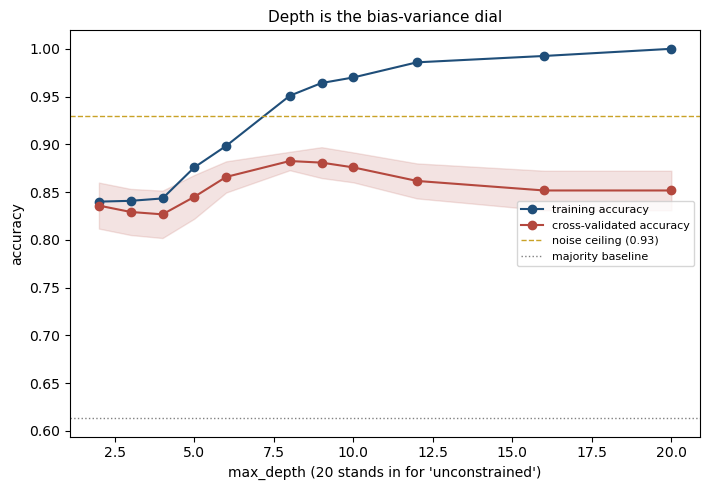

best depth: 8, cv accuracy 0.882


In [7]:
fig, ax = plt.subplots(figsize=(7.2, 5.0))
plot_depths = [d if d is not None else 20 for d in depths]
ax.plot(plot_depths, depth_table["train"], "o-", color=BLUE, label="training accuracy")
ax.plot(plot_depths, depth_table["cv_mean"], "o-", color=RUST, label="cross-validated accuracy")
ax.fill_between(plot_depths,
                 depth_table["cv_mean"] - depth_table["cv_std"],
                 depth_table["cv_mean"] + depth_table["cv_std"],
                 color=RUST, alpha=.15)
ax.axhline(1 - 0.07, color=GOLD, linestyle="--", linewidth=1, label="noise ceiling (0.93)")
ax.axhline(baseline, color="grey", linestyle=":", linewidth=1, label="majority baseline")
ax.set_xlabel("max_depth (20 stands in for 'unconstrained')")
ax.set_ylabel("accuracy")
ax.set_title("Depth is the bias-variance dial", fontsize=11)
ax.legend(fontsize=8, loc="center right")
fig.tight_layout()
fig.savefig(FIGURES / "depth_curve.png", dpi=150, bbox_inches="tight")
plt.show()

best_row = depth_table.loc[depth_table["cv_mean"].idxmax()]
print(f"best depth: {best_row['depth']}, cv accuracy {best_row['cv_mean']:.3f}")

The peak sits at a depth in the high single digits — deep enough to isolate
both stressed islands, shallow enough to leave the flipped labels as
misclassifications rather than as leaves of their own. The unconstrained tree
reaches training accuracy 1.000 and *loses* cross-validated accuracy relative
to the peak — the clearest possible illustration that training accuracy of
1.000 is not a result, it is a property of the model class.

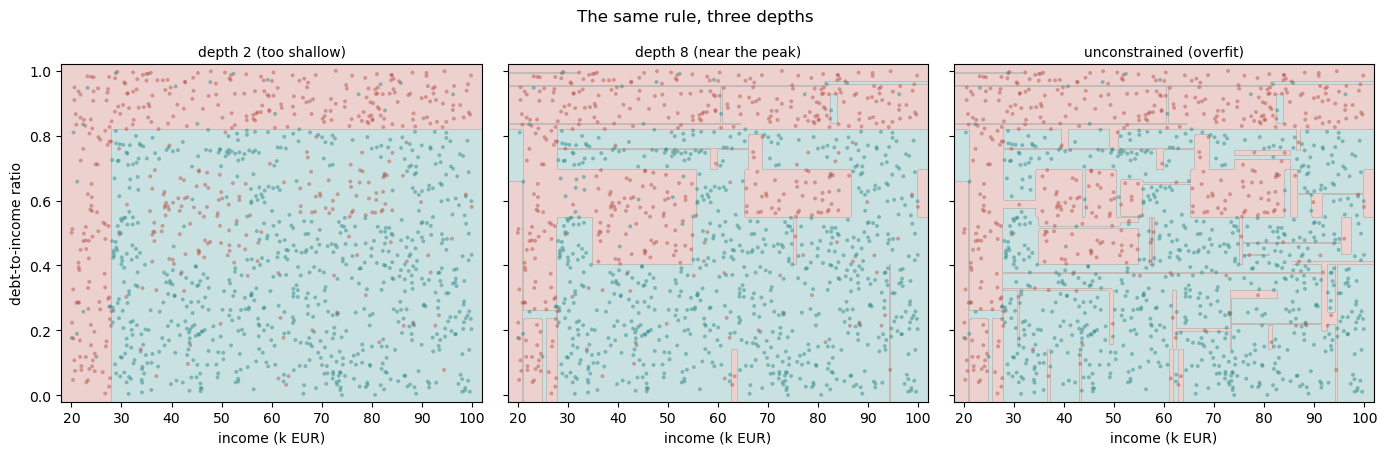

In [8]:
def plot_boundary(ax, model, title):
    xx, yy = np.meshgrid(np.linspace(18, 102, 300), np.linspace(-0.02, 1.02, 300))
    grid = pd.DataFrame({"income_k": xx.ravel(), "debt_ratio": yy.ravel()})
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-.5, .5, 1.5], colors=[TEAL, RUST], alpha=.25)
    ax.scatter(X.loc[healthy, "income_k"], X.loc[healthy, "debt_ratio"],
               s=8, color=TEAL, alpha=.5, edgecolor="none")
    ax.scatter(X.loc[default, "income_k"], X.loc[default, "debt_ratio"],
               s=8, color=RUST, alpha=.45, edgecolor="none")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("income (k EUR)")


fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharey=True)
axes[0].set_ylabel("debt-to-income ratio")
for ax, depth, label in zip(
        axes, [2, 8, None],
        ["depth 2 (too shallow)", "depth 8 (near the peak)", "unconstrained (overfit)"]):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X, y)
    plot_boundary(ax, tree, label)
fig.suptitle("The same rule, three depths", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "tree_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()

At depth 2 the tree can only afford two cuts, so it grabs the two biggest
regions — the income floor and the debt ceiling — and cannot see either
stressed island at all. At depth 8 both islands appear as clean rectangles,
close to the rule that generated the data. At full depth the boundary has
grown a fringe of tiny rectangles chasing individual flipped labels: not a
smoother version of the depth-8 boundary, a *noisier* one.

## 4. What a tree costs

`max_depth` grows the tree **breadth-first**: every leaf at level 3 is split
before any leaf reaches level 4, whether or not that particular split is
worth having. `max_leaf_nodes` grows it **best-first** instead — always
expanding whichever leaf currently offers the largest impurity reduction —
so a small leaf budget goes to the splits that matter most instead of being
spent evenly. For a printout meant to be read, that is the better knob.

In [9]:
small_tree = DecisionTreeClassifier(max_leaf_nodes=9, random_state=0).fit(X, y)
print(f"train accuracy: {small_tree.score(X, y):.3f}\n")
print(export_text(small_tree, feature_names=list(X.columns)))

train accuracy: 0.908

|--- debt_ratio <= 0.82
|   |--- income_k <= 28.06
|   |   |--- class: 1
|   |--- income_k >  28.06
|   |   |--- debt_ratio <= 0.40
|   |   |   |--- class: 0
|   |   |--- debt_ratio >  0.40
|   |   |   |--- debt_ratio <= 0.70
|   |   |   |   |--- debt_ratio <= 0.55
|   |   |   |   |   |--- income_k <= 58.00
|   |   |   |   |   |   |--- income_k <= 34.92
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- income_k >  34.92
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- income_k >  58.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- debt_ratio >  0.55
|   |   |   |   |   |--- income_k <= 86.62
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- income_k >  86.62
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- debt_ratio >  0.70
|   |   |   |   |--- class: 0
|--- debt_ratio >  0.82
|   |--- class: 1



That printout is the entire model, readable top to bottom, and it is the
thing k-nearest neighbours and support vector machines cannot offer: a
sequence of if/else statements a loan officer could apply by hand. Nine
leaves, 90.8% training accuracy, and every threshold is recognisable from
the generating rule: 28 for the income floor, 0.82 for the debt ceiling,
and the remaining splits tracing the outline of the two stressed islands.
This readability is not a side benefit — for a decision that has to be
justified to the person it affects, it can matter as much as accuracy. This
lesson's companion reading takes that further.

The other side of the ledger is **instability**. Change the training data
slightly and the tree that best reduces Gini impurity can change, because an
early split near the top reroutes everything beneath it.

In [10]:
sample_a = X.sample(frac=0.65, random_state=1)
sample_b = X.sample(frac=0.65, random_state=2)
tree_a = DecisionTreeClassifier(max_depth=6, random_state=0).fit(
    sample_a, y.loc[sample_a.index])
tree_b = DecisionTreeClassifier(max_depth=6, random_state=0).fit(
    sample_b, y.loc[sample_b.index])

agree = (tree_a.predict(X) == tree_b.predict(X)).mean()
print(f"root split, sample A: {X.columns[tree_a.tree_.feature[0]]} "
      f"<= {tree_a.tree_.threshold[0]:.3f}  ({tree_a.get_n_leaves()} leaves)")
print(f"root split, sample B: {X.columns[tree_b.tree_.feature[0]]} "
      f"<= {tree_b.tree_.threshold[0]:.3f}  ({tree_b.get_n_leaves()} leaves)")
print(f"agreement between the two trees on the full dataset: {agree:.3f}")

root split, sample A: debt_ratio <= 0.820  (31 leaves)
root split, sample B: debt_ratio <= 0.819  (33 leaves)
agreement between the two trees on the full dataset: 0.883


The root split barely moves — both trees find the debt ceiling within
0.001 of each other, because with 1,200 points the evidence for it is
overwhelming. What is *not* stable is everything downstream: 65% resamples
of the same data grow trees with different leaf counts (31 against 33 here)
and disagree on over a tenth of predictions between them, because the two
stressed islands
are supported by far fewer points each, and exactly which points land in a
given resample moves their boundaries around. A single tree's instability is
concentrated in its weaker splits, and that is the raw material the next
notebook turns into a strength: if a tree's mistakes are somewhat random,
*many* trees, averaged, cancel a lot of that randomness out.

## Summary

- A decision tree splits greedily on Gini impurity, one feature and one
  threshold at a time — verified here against scikit-learn to the fourth
  decimal place.
- Depth is the bias-variance dial: too shallow and the tree cannot represent
  the rule, too deep and training accuracy of 1.000 is bought by memorising
  noise. Cross-validated accuracy peaked around depth 8-9 in this dataset,
  well short of the unconstrained tree's training score.
- `max_leaf_nodes` (best-first growth) gives a more readable tree than
  `max_depth` (breadth-first) for the same budget of splits.
- A tree is readable but unstable: its strongest split survives resampling
  almost unchanged, but its weaker splits — the ones supported by fewer
  points — do not, and that is most of what determines its shape.

That instability is where notebook 2 starts.